In [ ]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
print("upload kaggle.json file:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Downloading dataset from Kaggle...")
!kaggle datasets download -d vjchoudhary7/customer-segmentation-tutorial-in-python --unzip

upload kaggle.json file:


Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
License(s): other
100% 1.55k/1.55k [00:00<00:00, 3.77MB/s]



In [ ]:
data = pd.read_csv('Mall_Customers.csv')
print("Our Data:")
data.head()
print(f"Total customers: {len(data)}")

Our Data:
Total customers: 200


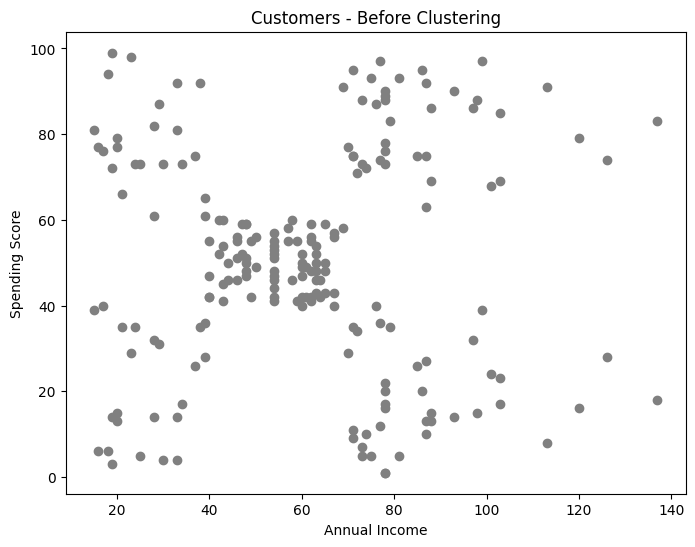

In [ ]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()
plt.figure(figsize=(8, 6))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c='gray')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customers - Before Clustering')
plt.show()

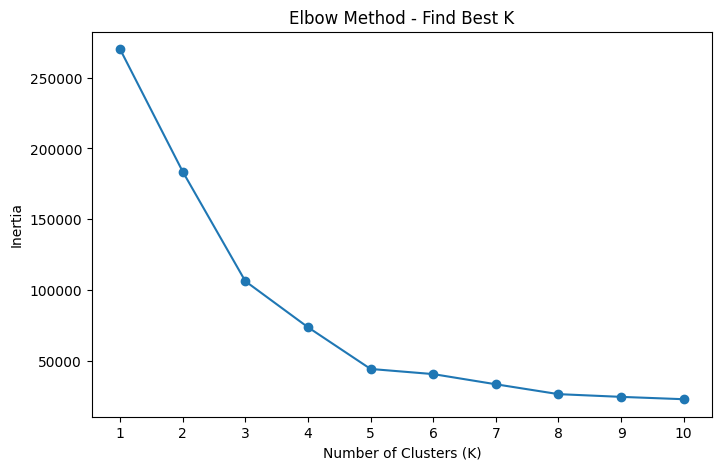

In [ ]:
inertia_list = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia_list.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_list, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Find Best K')
plt.xticks(range(1, 11))
plt.show()


First 10 customers with their clusters:



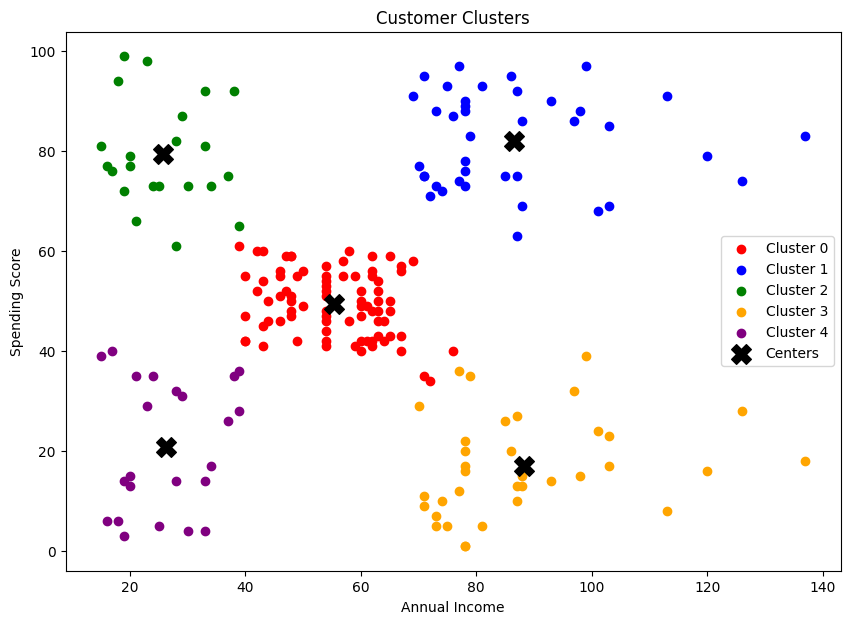

In [ ]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']].values
kmeans = KMeans(n_clusters=5, random_state=42)
data['Cluster'] = kmeans.fit_predict(X)
print("\nFirst 10 customers with their clusters:\n")
data.head(10)
plt.figure(figsize=(10, 7))

colors = ['red', 'blue', 'green', 'orange', 'purple']

for i in range(5):
    cluster_data = data[data['Cluster'] == i]
    plt.scatter(cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'],
                c=colors[i],
                label=f'Cluster {i}')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1],
            c='black', marker='X', s=200, label='Centers')

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Clusters')
plt.legend()
plt.show()

In [ ]:
cluster_summary = data.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_summary = cluster_summary.round(1)
print("Cluster Summary:\n")
print(cluster_summary)
print("\nCustomers per cluster:\n")
print(data['Cluster'].value_counts().sort_index())

Cluster Summary:

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                      55.3                    49.5
1                      86.5                    82.1
2                      25.7                    79.4
3                      88.2                    17.1
4                      26.3                    20.9

Customers per cluster:

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


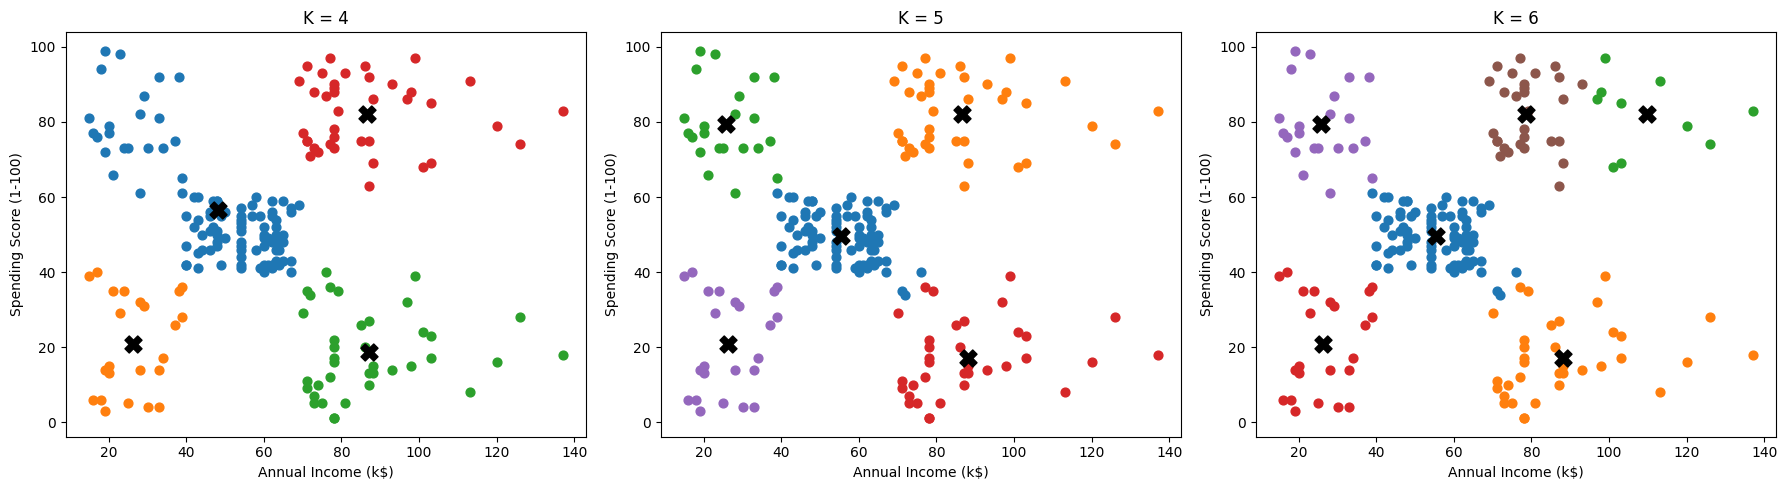

In [ ]:
k_values = [4, 5, 6]

plt.figure(figsize=(18, 5))

for idx, k in enumerate(k_values):
    kmeans_exp = KMeans(n_clusters=k, random_state=42, n_init=10)
    y_kmeans = kmeans_exp.fit_predict(X)
    plt.subplot(1, 3, idx + 1)
    for i in range(k):
        plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], s=40, label=f'Cluster {i}')
    centers_exp = kmeans_exp.cluster_centers_
    plt.scatter(centers_exp[:, 0], centers_exp[:, 1], c='black', marker='X', s=150, label='Centers')

    plt.xlabel('Annual Income (k$)')
    plt.ylabel('Spending Score (1-100)')
    plt.title(f'K = {k}')

plt.tight_layout()
plt.show()